In [1]:
using LinearAlgebra
using Plots
using QuadGK
using Roots
using FastGaussQuadrature

In [2]:
Nf = 4.0
m = 0.0037
w = 0.4
D = 0.93312 # 1.0
Lambda2 = 1e6
epsilon2 = 1e-4
Lambda_PV = 2e2
Lambda_QCD = 0.234
gamma_m = 0.48 # 12/(33 - 2 * Nf) = 0.48
mu = 19.0
z_2 = 1
z_4m = m;

In [3]:
F_UV(k2) = 2 * pi * gamma_m * (1 - exp(-k2)) / log(exp(2) - 1 + (1 + k2 / Lambda_QCD^2)^2)
G(k2) = D/w^6 * pi * k2^2 * exp(-k2 / w^2) + F_UV(k2);
pk(p, q, z) = p^2 - p*q*z
qk(p, q, z) = p*q*z - q^2
k2(p, q, z) = p^2 + q^2 - 2*p*q*z;

In [4]:
x, w_x = gausslegendre(100)
z, w_z = gausschebyshevu(20) # Chebyshev second kind
t = 0.5 * (log(Lambda2) - log(epsilon2)) * x .+ 0.5 * (log(Lambda2) + log(epsilon2))
w_t = 0.5 * (log(Lambda2) - log(epsilon2)) * w_x;

In [5]:
AA = 1.6 * ones(length(t))
BB = (m + 1e-3) * ones(length(t))
mu_i = argmin(abs.(t .- 2*log(mu)))

function z_intB(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * G(K2) / K2 * (Lambda_PV^2 / (K2 + Lambda_PV^2))
    return sum(integrand)
end

function z_intA(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * ( p*q*z + 2*pk(p, q, z)*qk(p, q, z)/K2 ) * G(K2) / K2 * (Lambda_PV^2 / (K2 + Lambda_PV^2))
    return sum(integrand)
end;

In [6]:
function part_A(p2, A, B, Z_2)
    integrand = @. w_t * exp(2*t) * A / (exp(t) * A^2 + B^2) * z_intA(sqrt(p2), exp(t/2))
    return Z_2 + Z_2^2 * 16pi/(3*(2pi)^3 * p2) * sum(integrand)
end

function part_B(p2, A, B, Z_2, Z_4m)
    integrand = @. w_t * exp(2*t) * B / (exp(t) * A^2 + B^2) * z_intB(sqrt(p2), exp(t/2))
    return Z_4m + Z_2^2 * 16pi/(2pi)^3 * sum(integrand)
end;

In [7]:
function update(A, B, Z_2, Z_4m)
    alpha = 0.2
    A_int = part_A.(exp.(t), Ref(A), Ref(B), Z_2)
    B_int = part_B.(exp.(t), Ref(A), Ref(B), Z_2, Z_4m)
    max_A = maximum(abs.(A .- A_int))
    max_B = maximum(abs.(B .- B_int))
    return alpha .* A_int .+ (1-alpha) .* A, alpha .* B_int .+ (1-alpha) .* B, 1 - A[mu_i] + Z_2, m - B[mu_i] + Z_4m, max(max_A, max_B)
    # return A_int, B_int, 1 - A[mu_i] + Z_2, m - B[mu_i] + Z_4m, max(max_A, max_B)
end;

In [8]:
for i in 1:100
    AA, BB, z_2, z_4m, maxerr = update(AA, BB, z_2, z_4m)
    if maxerr < 1e-6
        println("Finished: i = ", i)
        break
    end
end

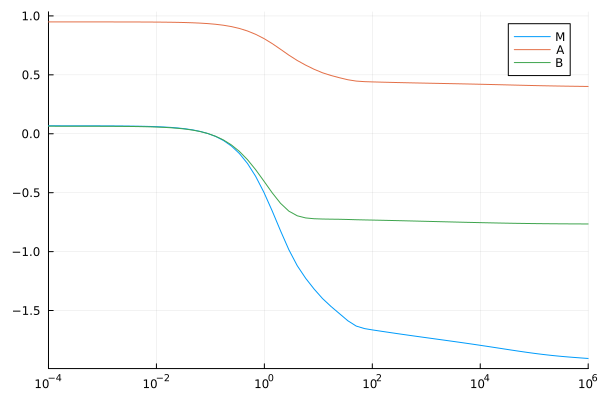

In [9]:
plot(exp.(t), BB./AA, xaxis=:log10, xlims = (epsilon2, Lambda2), label = "M")
plot!(exp.(t), AA, xaxis=:log10, xlims = (epsilon2, Lambda2), label = "A")
plot!(exp.(t), BB, xaxis=:log10, xlims = (epsilon2, Lambda2), label = "B")